# Amplitude encoding


In [1]:
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as TFN
import torchquantum as tq
import torchquantum.functional as tqf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
OUT_DIR = Path("results_amplitude_encoding_lensing")

for subdir in ("figures", "tables", "logs", "arrays"):
    (OUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"

CLASS_NAMES = ["no", "sphere", "vort"]
CLASS_LONG = {
    "no": "no_substructure",
    "sphere": "spherical_substructure",
    "vort": "vortex_substructure",
}

N_QUBITS = 10
TARGET_SIZE = 32
assert 2**N_QUBITS == TARGET_SIZE * TARGET_SIZE


## Data


In [2]:
def load_lensing_dataset(
    roots,
    class_names=CLASS_NAMES,
    target_size=TARGET_SIZE,
    max_per_class=None,
):
    if isinstance(roots, (str, Path)):
        roots = [roots]

    files = []
    for split_idx, root_dir in enumerate(roots):
        root_dir = os.fspath(root_dir)
        if not os.path.isdir(root_dir):
            continue

        folders = sorted(
            name for name in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, name))
        )
        for class_name in class_names:
            if class_name not in folders:
                continue

            class_dir = os.path.join(root_dir, class_name)
            class_files = sorted(
                name for name in os.listdir(class_dir)
                if name.endswith(".npy")
            )
            if max_per_class is not None:
                class_files = class_files[:max_per_class]

            files.extend(
                (os.path.join(class_dir, name), class_name, split_idx)
                for name in class_files
            )

    if not files:
        raise FileNotFoundError(f"No .npy files found in {roots}")

    def to_2d(array):
        if array.ndim == 2:
            return array
        if array.ndim == 3:
            if array.shape[0] == 1:
                return array[0]
            if array.shape[0] == 3:
                return array.mean(axis=0)
            if array.shape[2] == 3:
                return array.mean(axis=2)
            if array.shape[2] == 1:
                return array[..., 0]
        raise ValueError(f"Unexpected array shape {array.shape}")

    n_files = len(files)
    X = np.empty((n_files, target_size * target_size), dtype=np.float32)
    y = np.empty(n_files, dtype=object)
    splits = np.empty(n_files, dtype=np.int8)
    batch_size = 256
    batch_indices = []
    batch_images = []

    for row_idx, (file_path, label, split_idx) in enumerate(files):
        image = to_2d(np.load(file_path)).astype(np.float32)
        if image.max() > 1.0:
            image = image / 255.0

        batch_images.append(image)
        batch_indices.append(row_idx)
        y[row_idx] = label
        splits[row_idx] = split_idx

        if len(batch_images) < batch_size and row_idx != n_files - 1:
            continue

        batch = np.stack(batch_images, axis=0)
        if batch.shape[1:] != (target_size, target_size):
            tensor = torch.from_numpy(batch).unsqueeze(1)
            tensor = TFN.interpolate(
                tensor,
                size=(target_size, target_size),
                mode="bilinear",
                align_corners=False,
            )
            batch = tensor.squeeze(1).numpy()

        for local_idx, global_idx in enumerate(batch_indices):
            X[global_idx] = batch[local_idx].reshape(-1)

        batch_indices = []
        batch_images = []

    return X, y, splits


## State preparation


In [3]:
X_raw, y, splits = load_lensing_dataset(
    VAL_DIR,
    class_names=CLASS_NAMES,
    target_size=TARGET_SIZE,
)

norms = np.linalg.norm(X_raw, axis=1)
valid = norms > 1e-12
if not valid.all():
    X_raw = X_raw[valid]
    y = y[valid]
    splits = splits[valid]
    norms = norms[valid]

X_amp = X_raw.astype(np.float64) / norms[:, None]
plus_state = np.ones(X_amp.shape[1], dtype=np.float64) / np.sqrt(X_amp.shape[1])
class_counts = {class_name: int((y == class_name).sum()) for class_name in CLASS_NAMES}
cs_present = [class_name for class_name in CLASS_NAMES if class_counts[class_name] > 0]
min_class_count = min(class_counts[class_name] for class_name in cs_present)

np.save(OUT_DIR / "arrays" / "X_amp.npy", X_amp.astype(np.float32))
np.save(OUT_DIR / "arrays" / "y.npy", y)
np.save(OUT_DIR / "arrays" / "plus_state.npy", plus_state.astype(np.float32))


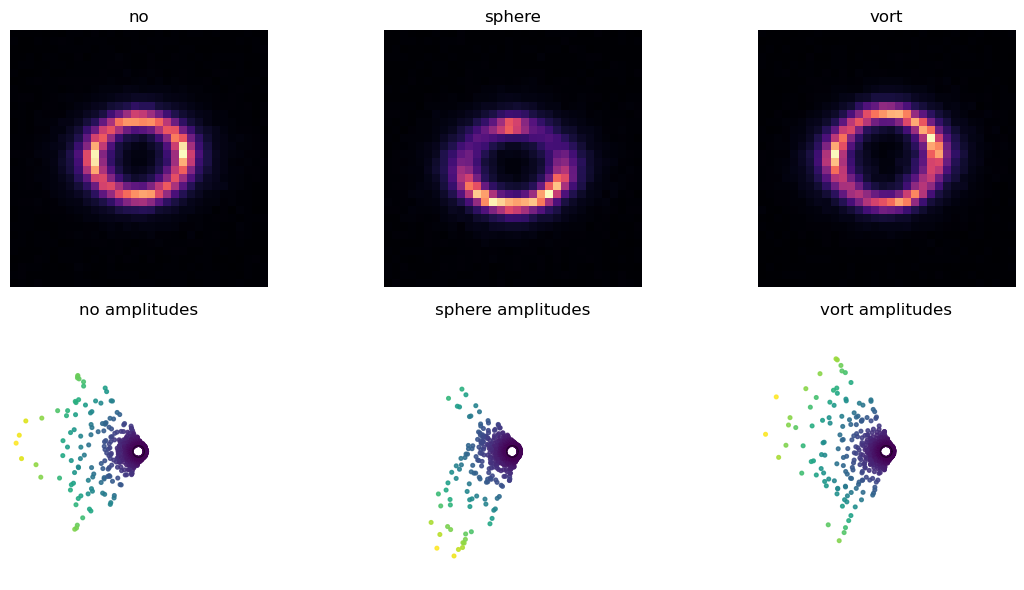

In [4]:
fig = plt.figure(figsize=(4 * len(cs_present), 6))
theta = np.linspace(0.0, 2.0 * np.pi, X_amp.shape[1], endpoint=False)

for col, class_name in enumerate(cs_present):
    idx = np.where(y == class_name)[0][0]
    image = X_raw[idx].reshape(TARGET_SIZE, TARGET_SIZE)
    amplitudes = X_amp[idx]
    scaled = amplitudes / amplitudes.max()

    ax_img = fig.add_subplot(2, len(cs_present), col + 1)
    ax_img.imshow(image, cmap="magma")
    ax_img.set_title(class_name)
    ax_img.set_axis_off()

    ax_amp = fig.add_subplot(2, len(cs_present), len(cs_present) + col + 1, projection="polar")
    ax_amp.plot(theta, np.ones_like(theta), color="black", linewidth=0.8, alpha=0.5)
    ax_amp.scatter(
        theta,
        1.0 + 0.45 * scaled,
        c=amplitudes,
        cmap="viridis",
        s=7,
        alpha=0.85,
    )
    ax_amp.set_title(f"{class_name} amplitudes")
    ax_amp.set_xticks([])
    ax_amp.set_yticks([])
    ax_amp.spines["polar"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "amplitude_encoding_circle.png", dpi=140)
plt.show()


## Encoder check


In [5]:
rng = np.random.default_rng(SEED)
test_idx = rng.choice(len(X_raw), size=4, replace=False)
raw_test = X_raw[test_idx].astype(np.float32)
manual_amp = raw_test / np.linalg.norm(raw_test, axis=1, keepdims=True)

encoder = tq.StateEncoder()
qdev = tq.QuantumDevice(n_wires=N_QUBITS, bsz=4)
encoder(qdev, torch.from_numpy(raw_test))
tq_state = qdev.get_states_1d().detach().cpu().numpy()
state_norms = np.linalg.norm(tq_state, axis=1)

assert np.max(np.abs(tq_state.real - manual_amp)) < 1e-5
assert np.max(np.abs(tq_state.imag)) < 1e-5
assert np.max(np.abs(state_norms - 1.0)) < 1e-5


## Trace distance


In [6]:
TD_DTYPE = torch.float64


def trace_distance_lowrank_gpu(W, signs, eps=1e-12, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(W, torch.Tensor):
        W = torch.from_numpy(np.asarray(W))
    W = W.to(device=device, dtype=dtype)

    if not isinstance(signs, torch.Tensor):
        signs = torch.from_numpy(np.asarray(signs))
    signs = signs.to(device=device, dtype=dtype)

    gram = W @ W.T
    gram = 0.5 * (gram + gram.T)
    evals, evecs = torch.linalg.eigh(gram)
    keep = evals > eps
    if not keep.any():
        return 0.0

    root = torch.sqrt(evals[keep]).unsqueeze(1) * evecs[:, keep].T
    signed = (root * signs.unsqueeze(0)) @ root.T
    signed = 0.5 * (signed + signed.T)
    eigvals = torch.linalg.eigvalsh(signed)
    return float((0.5 * torch.abs(eigvals).sum()).item())


def trace_distance_classes_gpu(Va, Vb, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(Va, torch.Tensor):
        Va = torch.from_numpy(np.asarray(Va))
    if not isinstance(Vb, torch.Tensor):
        Vb = torch.from_numpy(np.asarray(Vb))

    Va = Va.to(device=device, dtype=dtype)
    Vb = Vb.to(device=device, dtype=dtype)
    n_a, n_b = Va.shape[0], Vb.shape[0]
    W = torch.cat([Va / np.sqrt(n_a), Vb / np.sqrt(n_b)], dim=0)
    signs = torch.cat(
        [
            torch.ones(n_a, dtype=dtype, device=device),
            -torch.ones(n_b, dtype=dtype, device=device),
        ]
    )
    return trace_distance_lowrank_gpu(W, signs, device=device, dtype=dtype)


def trace_distance_to_pure_gpu(V, u, device=DEVICE, dtype=TD_DTYPE):
    if not isinstance(V, torch.Tensor):
        V = torch.from_numpy(np.asarray(V))
    if not isinstance(u, torch.Tensor):
        u = torch.from_numpy(np.asarray(u))

    V = V.to(device=device, dtype=dtype)
    u = u.to(device=device, dtype=dtype)
    n_samples = V.shape[0]
    W = torch.cat([V / np.sqrt(n_samples), u.unsqueeze(0)], dim=0)
    signs = torch.cat(
        [
            torch.ones(n_samples, dtype=dtype, device=device),
            -torch.ones(1, dtype=dtype, device=device),
        ]
    )
    return trace_distance_lowrank_gpu(W, signs, device=device, dtype=dtype)


probe_W = torch.randn(8, 16, dtype=TD_DTYPE, device=DEVICE)
probe_signs = torch.tensor([1, 1, 1, 1, -1, -1, -1, -1], dtype=TD_DTYPE, device=DEVICE)
_ = trace_distance_lowrank_gpu(probe_W, probe_signs)


## Sweep


In [7]:
X_amp_gpu = torch.from_numpy(X_amp).to(device=DEVICE, dtype=TD_DTYPE)
plus_state_gpu = torch.from_numpy(plus_state).to(device=DEVICE, dtype=TD_DTYPE)

m_values_all = [10, 25, 50, 100, 250, 500, 750, 1000, 1500, 2000]
N_SEEDS = 5
m_values = [m for m in m_values_all if m <= min_class_count]
if not m_values:
    raise ValueError("No sample sizes fit the available class counts")

t0 = time.time()
rows = []

for m in m_values:
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(SEED + 1000 * seed)
        sampled = {}

        for class_name in cs_present:
            idx = rng.choice(np.where(y == class_name)[0], size=m, replace=False)
            sampled[class_name] = torch.from_numpy(idx).to(device=DEVICE, dtype=torch.long)

        for class_name, idx in sampled.items():
            V = X_amp_gpu.index_select(0, idx)
            T = trace_distance_to_pure_gpu(V, plus_state_gpu)
            rows.append(
                {
                    "kind": "class_vs_plus",
                    "class_a": class_name,
                    "class_b": "|+>",
                    "m": m,
                    "seed": seed,
                    "T": T,
                }
            )

        for i, class_a in enumerate(cs_present):
            for class_b in cs_present[i + 1:]:
                Va = X_amp_gpu.index_select(0, sampled[class_a])
                Vb = X_amp_gpu.index_select(0, sampled[class_b])
                T = trace_distance_classes_gpu(Va, Vb)
                rows.append(
                    {
                        "kind": "between_classes",
                        "class_a": class_a,
                        "class_b": class_b,
                        "m": m,
                        "seed": seed,
                        "T": T,
                    }
                )

if torch.cuda.is_available():
    torch.cuda.synchronize()

sweep_seconds = time.time() - t0
df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / "tables" / "beyond_mnist_section_3_3_raw.csv", index=False)

g = (
    df.groupby(["kind", "class_a", "class_b", "m"])["T"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
g.to_csv(OUT_DIR / "tables" / "beyond_mnist_section_3_3_summary.csv", index=False)


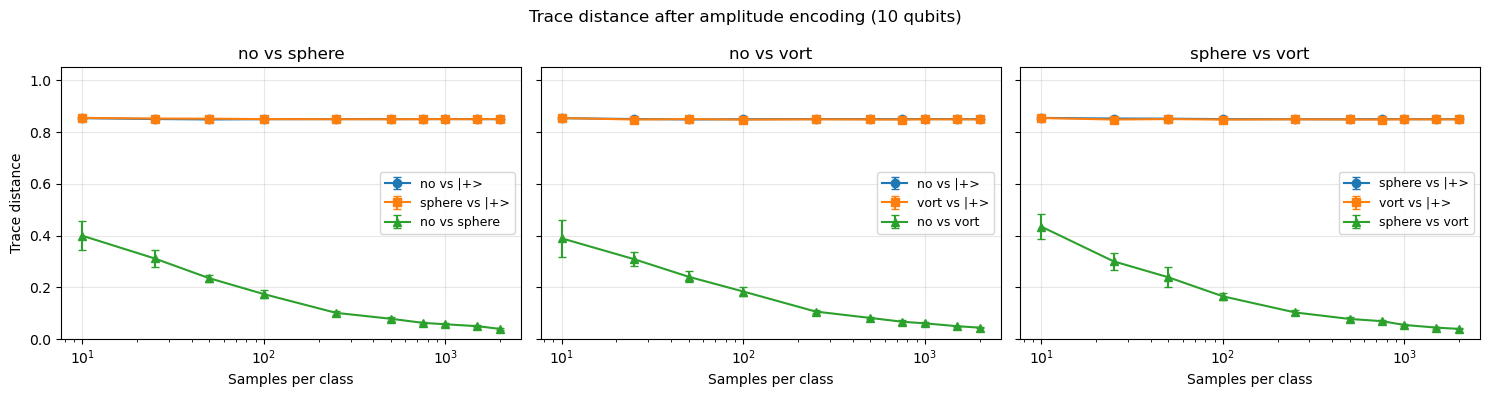

In [8]:
pairs = [
    (cs_present[i], cs_present[j])
    for i in range(len(cs_present))
    for j in range(i + 1, len(cs_present))
]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4), sharey=True)
if len(pairs) == 1:
    axes = [axes]

for ax, (class_a, class_b) in zip(axes, pairs):
    sub_a = g[
        (g["kind"] == "class_vs_plus")
        & (g["class_a"] == class_a)
    ].sort_values("m")
    sub_b = g[
        (g["kind"] == "class_vs_plus")
        & (g["class_a"] == class_b)
    ].sort_values("m")
    sub_ab = g[
        (g["kind"] == "between_classes")
        & (g["class_a"] == class_a)
        & (g["class_b"] == class_b)
    ].sort_values("m")

    ax.errorbar(
        sub_a["m"],
        sub_a["mean"],
        yerr=sub_a["std"],
        marker="o",
        capsize=3,
        label=f"{class_a} vs |+>",
    )
    ax.errorbar(
        sub_b["m"],
        sub_b["mean"],
        yerr=sub_b["std"],
        marker="s",
        capsize=3,
        label=f"{class_b} vs |+>",
    )
    ax.errorbar(
        sub_ab["m"],
        sub_ab["mean"],
        yerr=sub_ab["std"],
        marker="^",
        capsize=3,
        label=f"{class_a} vs {class_b}",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Samples per class")
    ax.set_title(f"{class_a} vs {class_b}")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Trace distance")
plt.suptitle(f"Trace distance after amplitude encoding ({N_QUBITS} qubits)")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "trace_distance_sweep.png", dpi=140)
plt.show()


## Circuit check


In [9]:
class FixedRandomPQC(nn.Module):
    def __init__(self, n_wires, n_layers=20, seed=0):
        super().__init__()
        self.n_wires = n_wires
        self.n_layers = n_layers
        rng = np.random.default_rng(seed)
        angles = rng.standard_normal(size=(n_layers, n_wires, 3)).astype(np.float32)
        self.angles = nn.Parameter(torch.from_numpy(angles), requires_grad=False)
        self.measure = tq.MeasureAll(tq.PauliZ)

    def forward(self, qdev):
        for layer_idx in range(self.n_layers):
            for wire in range(self.n_wires):
                tqf.rx(qdev, wires=wire, params=self.angles[layer_idx, wire, 0:1])
                tqf.ry(qdev, wires=wire, params=self.angles[layer_idx, wire, 1:2])
                tqf.rz(qdev, wires=wire, params=self.angles[layer_idx, wire, 2:3])
            for wire in range(self.n_wires):
                tqf.cnot(qdev, wires=[wire, (wire + 1) % self.n_wires])
        return self.measure(qdev)


def class_average_prob1_gpu(V_amp_gpu_idx, pqc, n_wires=N_QUBITS, batch_size=256, device=DEVICE):
    outputs = []
    for start in range(0, len(V_amp_gpu_idx), batch_size):
        batch = V_amp_gpu_idx[start:start + batch_size].to(torch.float32)
        qdev = tq.QuantumDevice(n_wires=n_wires, bsz=batch.shape[0], device=device)
        qdev.states = batch.to(torch.complex64).reshape((batch.shape[0],) + (2,) * n_wires)
        z = pqc(qdev)
        prob_one = (1.0 - z) / 2.0
        outputs.append(prob_one.detach().cpu().numpy())
    return np.concatenate(outputs, axis=0).mean(axis=0)


N_PQC = 5
N_LAYERS = 20
M_VERIFY = min(500, min_class_count)

rng_v = np.random.default_rng(SEED + 9999)
sampled_idx = {
    class_name: torch.from_numpy(
        rng_v.choice(np.where(y == class_name)[0], size=M_VERIFY, replace=False)
    ).to(device=DEVICE, dtype=torch.long)
    for class_name in cs_present
}

T_pair = {}
for i, class_a in enumerate(cs_present):
    for class_b in cs_present[i + 1:]:
        T_pair[(class_a, class_b)] = trace_distance_classes_gpu(
            X_amp_gpu.index_select(0, sampled_idx[class_a]),
            X_amp_gpu.index_select(0, sampled_idx[class_b]),
        )

verify_rows = []
for pqc_seed in range(N_PQC):
    pqc = FixedRandomPQC(N_QUBITS, n_layers=N_LAYERS, seed=pqc_seed).to(DEVICE).eval()
    p1 = {
        class_name: class_average_prob1_gpu(X_amp_gpu.index_select(0, idx), pqc)
        for class_name, idx in sampled_idx.items()
    }

    for i, class_a in enumerate(cs_present):
        for class_b in cs_present[i + 1:]:
            diffs = np.abs(p1[class_a] - p1[class_b])
            for qubit in range(N_QUBITS):
                verify_rows.append(
                    {
                        "pair": f"{class_a} vs {class_b}",
                        "pqc_seed": pqc_seed,
                        "qubit": qubit,
                        "abs_obs_diff": float(diffs[qubit]),
                        "T": float(T_pair[(class_a, class_b)]),
                        "bound_2T": float(2 * T_pair[(class_a, class_b)]),
                    }
                )

df_v = pd.DataFrame(verify_rows)
df_v.to_csv(OUT_DIR / "tables" / "beyond_mnist_holder_verification.csv", index=False)

g_v = (
    df_v.groupby("pair")
    .agg(
        max_abs_diff=("abs_obs_diff", "max"),
        mean_abs_diff=("abs_obs_diff", "mean"),
        T=("T", "first"),
        bound_2T=("bound_2T", "first"),
    )
    .reset_index()
)
g_v["bound_holds"] = g_v["max_abs_diff"] <= g_v["bound_2T"] + 1e-6
g_v.to_csv(OUT_DIR / "tables" / "circuit_bound_summary.csv", index=False)


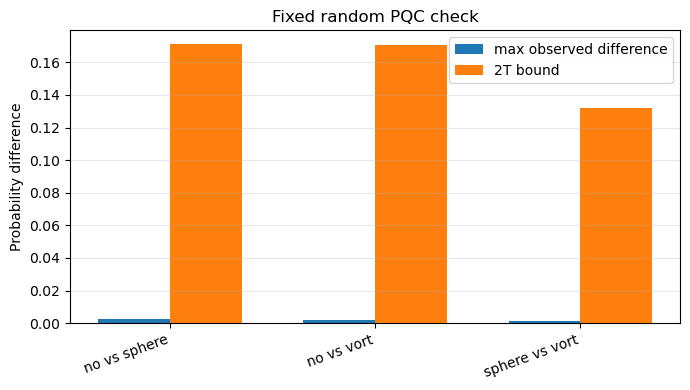

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(g_v))
width = 0.35

ax.bar(x - width / 2, g_v["max_abs_diff"], width, label="max observed difference")
ax.bar(x + width / 2, g_v["bound_2T"], width, label="2T bound")
ax.set_xticks(x)
ax.set_xticklabels(g_v["pair"], rotation=20, ha="right")
ax.set_ylabel("Probability difference")
ax.set_title("Fixed random PQC check")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "pqc_bound_check.png", dpi=140)
plt.show()
